# **Introdução ao Aprendizado Profundo**
<font size=3>

O **Aprendizado Profundo** (*Deep Learning*) é uma subárea do **Aprendizado de Máquina** que tem transformado diversas aplicações da Inteligência Artificial, desde reconhecimento de voz e visão computacional até processamento de linguagem natural. Sua principal característica é o uso de **redes neurais artificiais** com múltiplas camadas — também chamadas de redes profundas — que permitem a modelagem de padrões complexos a partir de grandes volumes de dados.

Inspiradas no funcionamento do cérebro humano, essas redes são compostas por unidades chamadas **neurônios artificiais**, organizadas em camadas interconectadas. Ao longo do treinamento, essas redes aprendem a extrair automaticamente representações de alto nível dos dados brutos, tornando-se ferramentas poderosas para tarefas de classificação, regressão, geração de conteúdo e muito mais.


## **1. O _hype_ do _deep learning_:**
<font size=3>

O Deep Learning trata-se de apenas um ramo da área de Machine Learning, que vem se desenvolvendo desde a década de 1960. Então, por que há tanto entusiasmo em DL, entre outras formas de ML? Bem, uma **vantagem que podemos destacar é a capacidade de modelar redes neurais cada vez mais robustas** (mais profundas) para resolver problemas mais complexos.

<font size=3><center>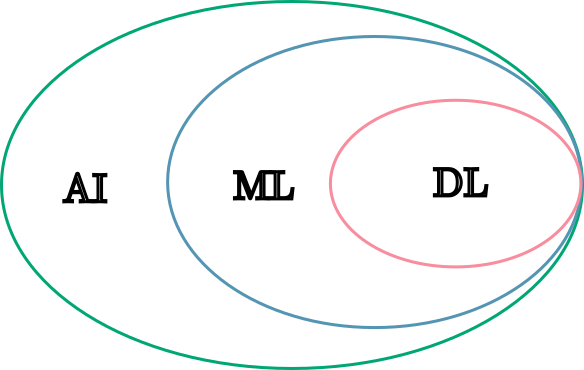</center>

<font size=3>
    
Sua abordagem baseia-se na modelagem matemática de redes neurais (biológicas), onde o disparo de **neurônios artificiais** gera um _"caminho"_ entre os dados de entrada e a saída do modelo de rede. Modelos com apenas uma camada de neurônios como saída são chamados de modelos de **Aprendizado Raso** (Shallow Learning). Por outro lado, modelos que apresentam múltiplas camadas, entre a entrada e a saída, codificam os padrões de dados com mais detalhes/profundidade durante o treinamento. Por isso, são chamados de modelos de Aprendizado Profundo (terminologia cunhada por [Rina Dechter, 1980](https://aaai.org/papers/00178-aaai86-029-learning-while-searching-in-constraint-satisfaction-problems/)).

<font size=3><center>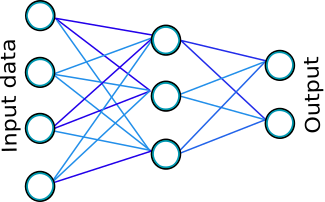</center>

## **2. _Multilayer Perpectron_:**

### **2.1 O _perceptron_:**
<font size=3>

O [perceptron](https://en.wikipedia.org/wiki/Perceptron) é um modelo analógico de processamento de sinais desenvolvido na década de 1950. Mais tarde, tornou-se o modelo matemático mais básico de um neurônio, cuja função
\begin{equation}
    f(\vec a) =
    \begin{bmatrix}
        1,\; \vec w \cdot \vec a + b > 0\\
        0,\; \vec w \cdot \vec a + b \leq 0
     \end{bmatrix} \, ,
\end{equation}
recebe um sinal de entrada $\vec a$; o vetor peso (_weight_) $\vec w$ escalona o sinal, e o viés (_bias_) $b$ ajusta a uma saída binária $[0,\,1]$.

O neurônio artificial, $a_1 = \vec w \cdot \vec a_0 + b$, pode ser ilustrado como um grafo:<font size=3>

<font size=3><center>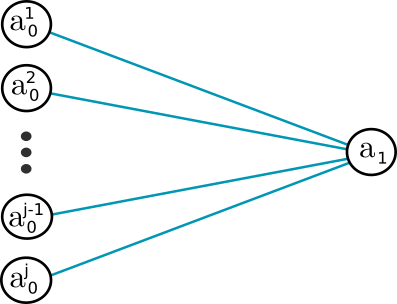</center>

<font size=3>

Para melhorar a **robustez** do nosso modelo linear, vamos considerar um **sinal de saída** $\vec a$ em vez de uma classificação binária,
$$
    a_1^i = W_1^{ij}\, a_0^j + b_1^i \, ,
$$
tal que, temos agora, a matriz _weight_ $W_1^{ij}$ e o vetor _bias_ $b_1^i$. Os índices $(i,\,j) = [1,2,3,\dots]$ variam de acordo com o tamanho da saída $\vec a_1$ e entrada $\vec a_0$.

<font size=3><center>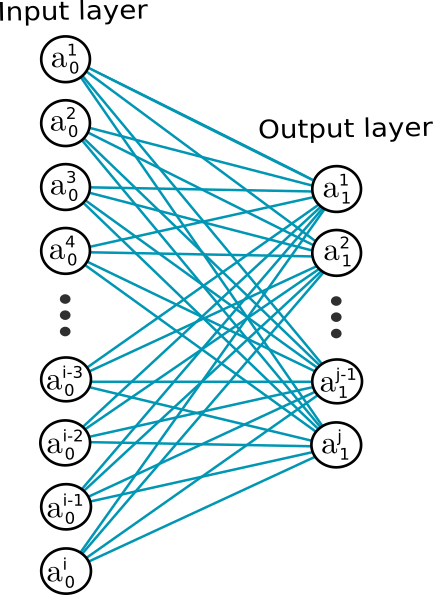</center>

### **2.2 A rede neural:**
<font size=3>

Esses grupos verticais de neurônios são chamados de **camadas** (*layers*). Para *aprofundar* nossa **rede neural** (*neural network* — NN) adicionando camadas entre a entrada e a saída, precisamos redefinir nossa função *perceptron*. Para quebrar a linearidade dessa função, vamos nos inspirar no [potencial de ação](https://en.wikipedia.org/wiki/Action_potential) das [sinapses](https://en.wikipedia.org/wiki/Synapse).

O perceptron linear agora se tornará o argumento de uma **função de ativação** não-linear $\sigma_l$. Para simplificar, consideraremos todos os neurônios da camada $l$ com a mesma função de ativação, mas cada camada pode ter sua própria função. O modelo do **_Multilayer Perceptron_ (MLP)** pode ser escrito como,
$$
    a_l^i = \sigma_l\left(W_l^{ij}a_{l-1}^j + b_l^i\right) \, .
$$

<font size=3><center>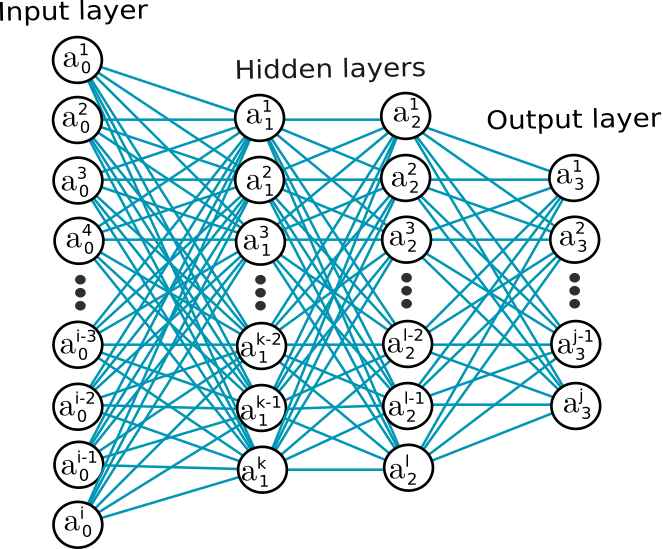</center>

<font size=3>
    
Algumas terminologias relacionadas à ilustração acima incluem MLP, **rede neural** (NN) e **camadas densas** (porque são densamente conectadas). Essas camadas entre a entrada (*input layer*) e a saída (*output layer*) são chamadas de **camadas ocultas** (*hidden layers*), pois são "desconhecidas" antes da modelagem NN.

### **2.3 Funções de ativação:**
<font size=3>

Uma simples [função de ativação](https://en.wikipedia.org/wiki/Activation_function) pode ser pensada como a [função de Heaviside](https://en.wikipedia.org/wiki/Heaviside_step_function) $[f(x) = 1,\, x \geq 0;\; 0,\, x < 0]$ para modelar quando o **neurônio dispara**. No entanto, **funções lineares não permitem construir matematicamente camadas ocultas**. Como alternativa, nós iremos considerar uma forma aproximada e não-linear, a **função sigmoid**,
$$
    f(x) = \frac{1}{1 + e^{-x}} \, .
$$

Outra função, de aplicação mais moderna pela sua simplicidade e rapidez computacional, é a função **_Rectified Linear Unit_ (ReLU)**,
$$
    \text{ReLU}(x) = \max(x, 0) \, .
$$

<br>

**Observação:** *A escolha das funções de ativação irão depender da modelagem e tipo de tarefa a ser resolvida.*


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
x = np.linspace(-10, 10, 200)

H = np.heaviside(x, 0.0)

σ = 1/(1 + np.exp(-x))

relu = np.maximum(x, 0)

plt.figure(figsize=(6, 4))
plt.plot(x, H, label="Heaviside(x)")
plt.plot(x, σ, label="Sigmoid(x)")
plt.plot(x, relu, label="ReLU(x)")
plt.xlabel(r'$x = W\cdot a + b$')
plt.ylim(-0.05, 2.05)
plt.xlim(-5, 5)
plt.legend()
plt.grid()
plt.show()

<font size=3>

**Observe** que para um melhor desempenho de "disparos" de neurônios, os dados $x$ que passam pelas funções de ativações precisam estar **normalizados**. Por exemplo, se os dados apresentam valores altos, $x \in [10^2,\,10^3]$, a sigmoid **sempre** estará "ativada", o que não propicia um padrão de conexões entre os neurônios que possam extrair as *features* dos dados de entrada.  

### **2.4 A Função de perda:**
<font size=3>

Surge uma pergunta: Quais são os parâmetros internos (*weigths* e *bias*) que permitem à rede neural artificial fazer previsões precisas?

Inicialmente, **os parâmetros são definidos aleatoriamente** (normalmente usando a **inicialização Xavier**); em seguida, enquanto os dados passam pela NN, os *weights* e *bias* são atualizados para otimizar (maximizar ou minimizar) a **função de perda** (este é o mecanismo de **gradiente descendente**, que veremos mais à frente).

Considerando um modelo **supervisionado**, uma possível escolha de função de perda pode ser o **erro quadrático médio**,
$$
    \mathcal L(y,\, \hat y) = \left<(y - \hat y)^2\right> \, ,
$$
onde $y$ os **dados alvos** e $\hat y$ é a **previsão do modelo**.

Quando todo o conjunto de dados passa pela rede neural artificial e os parâmetros são ligeiramente otimizados, contamos **uma época**. Para manter a otimização dos parâmetros em constante aprimoramento, treinamos a NN por **várias épocas**. Por quantas épocas, então? **Até que a otimização comece a saturar ou piorar** (veremos a seguir!).


## **3. A otimização do modelo:**
<font size=3>

**Como _weights_ e _bias_ são ajustados?!** Para ajustar esses parâmetros, nós precisamos primeiro saber o quanto a função de perda $\mathcal L$ muda, pela variação dos parâmetros $\left(W_l^{ij},\, b_l^i\right)$. Isto é o mesmo que perguntar sobre *a __taxa de mudança__ de $\mathcal L$ em relação aos parâmetros internos* ou *a __derivada__ de $\mathcal L$ em relação à $\left(W_l^{ij},\, b_l^i\right)$*.


### **3.1 O poder de _gradiente_:**
<font size=3>

No **Cálculo**, nós expressamos as derivadas utilizando diferentes notações com base no tipo de operação que queremos calcular. Para funções de múltiplas variáveis $f(x,\,y)$, nós escrevemos a **derivada parcial** de $f$ em relação a $x$ como $\partial f(x,\,y)/\partial x$, ou em relação a $y$ como $\partial f(x,\, y)/\partial y$, usando o símbolo matemático $\partial$ ("del").

O *operador gradient* $\vec \nabla$ — escrito com o símbolo $\nabla$ ("nabla") — é uma quantidade vetorial que expressa as derivadas parciais de uma função nos eixos do plano cartesiano,
$$
    \vec\nabla f(x,\,y) = \frac{\partial f}{\partial x}\,\hat x + \frac{\partial f}{\partial y}\,\hat y \, .
$$

Se nós calcularmos $\vec\nabla f(x,\,y) = 0$, nós obteremos a direção e magnitude dos valores máximo/mínimo de $f(x,\,y)$. Desta forma, **podemos identificar quais parâmetros do modelo otimiza a função de perda!**

<br>

Para compreender como a função de perda é função de *weights* e *bias*, vamos usar a função MSE como exemplo,
$$
    \mathcal L = \left<\left(y^i - \hat y^i\right)^2\right> = \left<\left(y^i - a_L^i\right)^2\right> \, ,
$$
onde a predição $\hat y^i = a_L^i$, *i.e.*, a camada de saída definida pelo índice $l=L$. Assim, temos que $a_L^i$ é função dos parâmetros internos, uma vez que
$$
    a^i_l = \sigma_l\left(W_l^{ij}\,a_{l-1}^j + b_l^i\right) \, ,\quad l = (1,\dots, L)\, .
$$

Para ilustrar a função de perda $\mathcal L$ em um plote tridimensional, vamos simplificar a notação dos parâmetros internos como $\omega_i \equiv \left(W_l^{ij},\, b_l^i\right)$. Abaixo, segue um exemplo de superfície de função de perda considerando dois parâmetros $(\omega_1,\, \omega_2)$.

In [ ]:
import tensorflow as tf

In [ ]:
x = tf.linspace(-20, 20, 50)
y = tf.linspace(-20, 20, 50)

ω1, ω2 = tf.meshgrid(x, y)

def loss(ω1, ω2):
    return -tf.exp(-0.02*(ω1**2 + 0.4*ω2**2) + 0.5*tf.cos(0.8*ω1) + 0.2*tf.cos(0.5*ω2))

L = loss(ω1, ω2)

fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(10,7))
ax.plot_surface(ω1, ω2, L, alpha=0.8)
ax.set_xlabel(r"$\omega_1$", fontsize=12)
ax.set_ylabel(r"$\omega_2$", fontsize=12)
plt.show()

<font size=3>

Na figura seguinte, temos o gradiente $\vec\nabla\mathcal L$ como os vetores resultantes de cada ponto do plano $(\omega_1,\,\omega_2)$. Os vetores apontam para fora, para o valor mínimo de $\mathcal L$, por se tratar de um valor negativo.

Quando a arquitetura do modelo é definida, *weights* e *bias* são estabelecidos randomicamente, o que resulta em um **valor alto da função de perda na primeira época**. Para encontrar os melhores valores de $\omega_i$ que otimize $\mathcal L$, nós iremos aplicar $\vec\nabla\mathcal L(\vec\omega) = 0$. Este processo, na prática, é o que chamamos do **mecanismo do gradiente descendente**.

In [ ]:
with tf.GradientTape() as tape:
    tape.watch(ω1)
    tape.watch(ω2)

    L = loss(ω1, ω2)

dL = tape.gradient(L, [ω1, ω2])

plt.title("Figure 5")
plt.contourf(ω1, ω2, L)
plt.quiver(ω1, ω2, dL[0], dL[1])
plt.xlabel(r"$\omega_1$", fontsize=12)
plt.ylabel(r"$\omega_2$", fontsize=12)
plt.colorbar(label='loss function')
plt.show()

### **3.2 O mecanismo do _gradiente descendente_:**
<font size=3>

O método mais simples para a *"descida do gradiente"* ajusta *weights* e *bias*, representados por $\omega_i$, de acordo com a equação,
$$
    \vec\omega \rightarrow \vec\omega - \eta\vec\nabla\mathcal L \, ,
$$
onde "$\rightarrow$" significa *"torna-se"*, e o hiperparâmetro $\eta$ é conhecido como **taxa de aprendizado** (*learning rate*).

Geralmente, a taxa de aprendizado é definida como $\eta = 0.01$. Este é um parâmetro complicado, pois se aumentarmos seu valor, os valores ótimos de $\omega_i$  não poderão ser encontrados, pois ele saltará de um valor para outro **sem atingir o valor ótimo da função de perda**. Por outro lado, se for muito pequeno, o ajuste pode levar muito tempo e **pode ficar preso em um valor máximo/mínimo local**.


### **3.3 O método do _gradiente descendente estocástico_:**
<font size=3>

Considerando o aprendizado supervisionado, o conjunto de dados é formado por um grupo de $(\vec x_1,\, \vec x_2,\, \dots,\, \vec x_n)$ e $(\vec y_1,\, \vec y_2,\, \dots,\, \vec y_n)$. A partir da equação do gradiente descendente, *weights* e *bias* são ajustados para cada par $(\vec x,\, \vec y)$ de dados. Quando todos os $n$ pares passam pela NN (fazendo ajustes), temos **uma época**. Assim, continuamos a otimização por tantas épocas quanto possível até que a saturação do aprendizado ou o valor da função de perda piore.

Para acelerar o aprendizado da NN, em vez de fazer $n$ ajustes, podemos agrupar os dados em lotes (__*batches*__) de modo que *1-batch* $= [(\vec x_1,\, \vec x_2,\, \dots,\, \vec x_m), \, (\vec y_1,\, \vec y_2,\, \dots,\, \vec y_m)]$, onde *m* é o tamanho do lote (__*batch-size*__) (veja a ilustração abaixo).

<font size=3><center>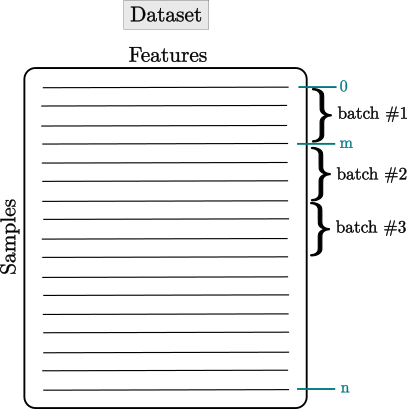</center>

<font size=3>
    
Assim, o vetor de entrada $a_0^i$ torna-se uma matriz $a_0^{ik}$, para $k=(1,\,\dots,\, m)$, e as camadas densas são calculadas por
$$
    a^{ik}_l = \sigma_l\left(W_l^{ij}\,a_{l-1}^{jk} + b_l^i\right) \, .
$$

Ao aplicar o gradiente descendente, nós não precisamos fazer $n$ ajustes, mas $(n/m)$ ajustes, já que agora podemos calcular a média de $\vec\nabla\mathcal L$ em relação a $m$-*batches*,
\begin{align}
    &\mathcal L_{total} = \left<\left(y^i - a_L^i\right)^2\right> \rightarrow \frac{1}{m}\sum_{k=1}^m\left<\left(y^{ik} - a_L^{ik}\right)^2\right> = \frac{1}{m}\sum_{k=1}^m\mathcal L_k = \left<\mathcal L\right>_m \, ,\\
    &\vec\nabla\mathcal L_{total} = \vec\nabla\left<\mathcal L\right>_m = \left<\vec\nabla\mathcal L\right>_m \, ,
\end{align}
assim, o gradiente descendente é reescrito como
$$
    \vec\omega \rightarrow \vec\omega - \eta\,\left<\vec\nabla\mathcal L\right>_m\, .
$$

Este método adaptado é, então, conhecido por **gradiente descendente estocástico** (*stochastic gradient descent* — SGD). O "estocástico" vem do processo de embaralhamento das amostras dos dados antes de dividi-los em $m$ *batches*. O método SGD é um dos **otimizadores** mais simples; existem vários outros métodos que são rápidos e robustos para encontrar os melhores parâmetros do modelo.

### **3.4 O algoritmo da _Propagação Reversa_:**
<font size=3>

Antes de fechar nosso estudo introdutório, precisamos responder **como o gradiente da função de perda $\vec\nabla\mathcal L$ é calculado**. Por meio do cálculo, podemos deduzir o **algoritmo da propagação reversa** (*backpropagation*), que diz que,
\begin{align}
     \frac{\partial\mathcal L}{\partial W_l^{ij}} &= \gamma_l^i\,a_{l-1}^j \, , \\
     \frac{\partial\mathcal L}{\partial b_l^i} &= \gamma_l^i \, ,\\
\end{align}
onde o vetor $\gamma^i_l$, é dado por
\begin{align}
    \gamma_l^i &=
    \begin{bmatrix}
        \dfrac{\partial\mathcal L}{\partial a_l^i}\,\sigma'_l\left(c^i_l\right) \, ,\quad l = L \\
        \gamma_{l+1}^k\,W_{l+1}^{ki}\,\sigma'_l\left(c^i_l\right) \, ,\quad l \neq L
     \end{bmatrix} \, ,
\end{align}


<details>
<summary>Dedução matemática do algoritmo:</summary>

Vamos definir a função da camada densa como $a_l^i = \sigma_l(c_l^i)$, onde $\,c_l^i = W_l^{ij}\,a_{l-1}^j + b_l^i\,$ é o perceptron linear. Lembrando que $\omega_i = \left(W_l^{ij},\, b_l^i\right)$, o gradinte da função de perda fica,
$$
    \vec\nabla\mathcal L = \left(\frac{\partial\mathcal L}{\partial\omega_1},\, \frac{\partial\mathcal L}{\partial\omega_2},\,\dots\right) \, ,
$$
tal que todas as componentes são calculadas na forma
\begin{align}
    &\frac{\partial\mathcal L}{\partial\omega_i} = \frac{\partial\mathcal L}{\partial a_l^i}\left(\frac{\partial\mathcal a_l^i}{\partial\omega_i}\right) = \frac{\partial\mathcal L}{\partial a_l^i}\left(\frac{\partial \sigma_l}{\partial c_l^i}\frac{\partial c_l^i}{\partial \omega_i}\right) = \gamma_l^i \frac{\partial c_l^i}{\partial \omega^i} \, ;\quad l = L \, ,\\
    &\gamma_l^i \equiv \frac{\partial \mathcal L}{\partial c_l^i} = \frac{\partial \mathcal L}{\partial a_l^i}\sigma'_l\left(c_l^i\right) \, .
\end{align}

Agora, vamos calcular _weights_ e _biases_ separadamente,
\begin{align}
    \vec\nabla\mathcal L &= \left(\frac{\partial\mathcal L}{\partial W_l^{ij}},\, \frac{\partial\mathcal L}{\partial b_l^i}\right) \, ,\\\\
    \frac{\partial \mathcal L}{\partial W_l^{ij}} &= \gamma_l^i\frac{\partial c_l^i}{\partial W_l^{ij}} = \gamma_l^i\frac{\partial }{\partial W_l^{ij}}\left(W_l^{ik}\,a_{l-1}^k + b_l^i\right) = \gamma_l^i\,\delta^{jk}\,a_{l-1}^k = \gamma_l^i\, a_{l-1}^j \, ;\quad l = L\, ,\\
    \frac{\partial \mathcal L}{\partial b_l^i} &= \gamma_l^i\frac{\partial c_l^i}{\partial b_l^i} = \gamma_l^i\frac{\partial }{\partial b_l^i}\left(W_l^{ik}\,a_{l-1}^k + b_l^i\right) = \gamma_l^i \, ;\quad l = L\, .
\end{align}

Repire função e observe: o cálculo acima está relacionado à camada $l=L$, porque, _e.g._, o gradiente da função de perda MSE é dado por
$$
    \frac{\partial\mathcal L}{\partial \omega_i} = \frac{\partial }{\partial \omega_i}\left<\left[y^i - a_L^i(\omega_i)\right]^2\right> = -2\left<y^i - a_L^i(\omega_i)\right>\frac{\partial a_L^i(\omega_i)}{\partial \omega_i} \, .
$$

Para incluir todas as camada (__voltando__ para $l=L$) na cálculo do gradiente, iremos realizar o seguinte truque,
\begin{align}
    \gamma_l^i &= \frac{\partial\mathcal L}{\partial c_l^i} = \frac{\partial\mathcal L}{\partial c_{l+1}^k}\frac{\partial c_{l+1}^k}{\partial c_l^i} = \gamma_{l+1}^k\frac{\partial }{\partial c_l^i}\left(W_{l+1}^{kj}\,a_l^j + b_{l+1}^k\right) \, ;\quad a_l^j = \sigma_l\left(c_l^j\right) \, ,\\
    &= \gamma_{l+1}^k\,W_{l+1}^{kj}\,\sigma'_l\left(c_l^j\right)\,\delta^{ij} = \gamma_{l+1}^k\,W_{l+1}^{ki}\,\sigma'_l\left(c_l^i\right) \, .
\end{align}

<br>

Porque calculamos $\vec\nabla\mathcal L$ pegando as contribuições de cada camada de modo _reverso_, $l=(L,\, L-1,\, \dots\, 1)$, este método é conhecido como o __algoritmo Backpropagation__.
</details>

<font size=3>

Com estes engredientes, podemos calcular o **otimizador** SGD, $\vec\omega \rightarrow \vec\omega - \eta\,\left<\vec\nabla\mathcal L\right>_m$, a fim de ajustar *weights* e *bias* da seguinte forma,
\begin{align}
    W_l^{ij} &\rightarrow W_l^{ij} - \eta\,\left<\frac{\partial\mathcal L}{\partial W_l^{ij}}\right>_m \, ,\\\\
    b_l^i &\rightarrow b_l^i - \eta\,\left<\frac{\partial\mathcal L}{\partial b_l^i}\right>_m \, .
\end{align}

## **Referências:**
<font size=3>
    
- F. Chollet, *Deep Learning with Python*. Manning, 2018.
- [But what is a neural network?](https://www.youtube.com/watch?v=aircAruvnKk&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi&index=2&t=216s)
- [Gradient descent, how neural networks learn.](https://www.youtube.com/watch?v=IHZwWFHWa-w&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi&index=3)
- [What is backpropagation really doing?](https://www.youtube.com/watch?v=Ilg3gGewQ5U&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi&index=4)
- [Backpropagation calculus.](https://www.youtube.com/watch?v=tIeHLnjs5U8&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi&index=5)

